In [1]:
%run stochastic_lite.ipynb

## Get O1 and O2 data

In [2]:
import requests

In [3]:
# taken from here: https://stackoverflow.com/questions/16694907/download-large-file-in-python-with-requests/16696317#16696317
def download_file(url):
    local_filename = url.split('/')[-1]
    # NOTE the stream=True parameter below
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(local_filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192): 
                # If you have chunk encoded response uncomment if
                # and set chunk_size parameter to None.
                #if chunk: 
                f.write(chunk)
    return local_filename

In [4]:
fname_O1=download_file('https://dcc.ligo.org/public/0139/G1602446/003/figure1.dat')
freqs_1,Y_f_1,two_sigma_f_1=np.loadtxt(fname_O1,unpack=True,skiprows=1)
sigma_f_1=two_sigma_f_1/2
var_f_1=sigma_f_1**2

HubbleConstantCorrection = 0.68**2 / 0.679**2 # H0 choice changed from O1 to O2
Y_f_1 = Y_f_1 * HubbleConstantCorrection
sigma_f_1 = sigma_f_1 * HubbleConstantCorrection
var_f_1 = var_f_1 * HubbleConstantCorrection**2

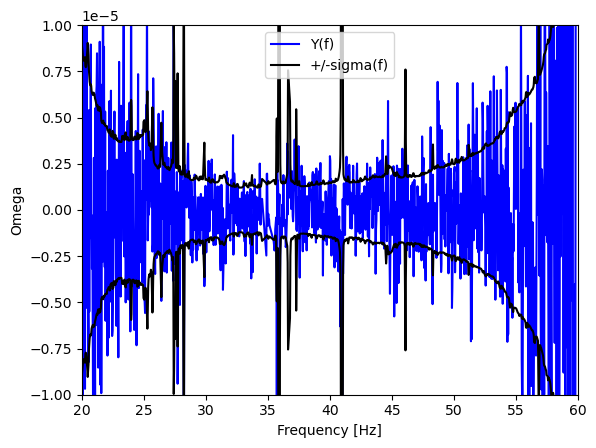

In [5]:
plt.plot(freqs_1,Y_f_1,color='blue',label='Y(f)')
plt.plot(freqs_1,sigma_f_1,color='black',label='+/-sigma(f)')
plt.plot(freqs_1,-sigma_f_1,color='black')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Omega')
plt.xlim(20,60)
plt.ylim(-1e-5,1e-5)
plt.legend()


In [6]:
fname_O2=download_file('https://dcc.ligo.org/public/0158/T1900058/003/Figure_1_Cf_spectra_O2.dat')
freqs_2,Y_f_2,sigma_f_2=np.loadtxt(fname_O2,unpack=True)
var_f_2=sigma_f_2**2

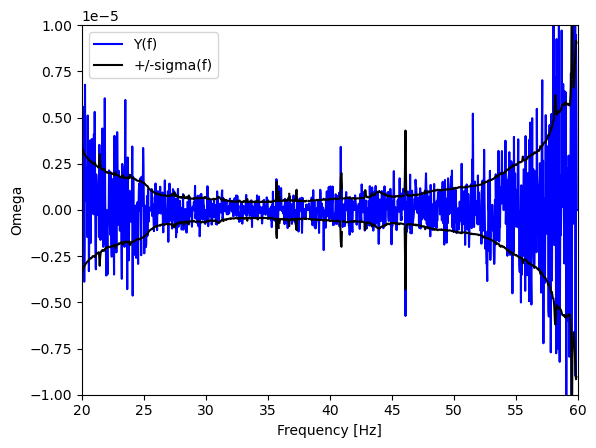

In [7]:
plt.plot(freqs_2,Y_f_2,color='blue',label='Y(f)')
plt.plot(freqs_2,sigma_f_2,color='black',label='+/-sigma(f)')
plt.plot(freqs_2,-sigma_f_2,color='black')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Omega')
plt.xlim(20,60)
plt.ylim(-1e-5,1e-5)
plt.legend()



In [8]:
cal_O1_H1 = 4.8 / 100
cal_O1_L1 = 5.4 / 100
cal_O2_H1 = 2.6 / 100
cal_O2_L1 = 3.85 / 100

cal_O1= np.sqrt(cal_O1_H1**2 + cal_O1_L1**2)
cal_O2= np.sqrt(cal_O2_H1**2 + cal_O2_L1**2)

#cal_O1=cal_O2

O1_data = Baseline('HL-O1',Y_f_1,var_f_1,freqs_1,calibration_epsilon=cal_O1)
O2_data = Baseline('HL-O2',Y_f_2,var_f_2,freqs_2,calibration_epsilon=cal_O2)

baselines=[O1_data,O2_data]


npoints=1024

# PE

In [9]:
label = 'GWB_powerlaw'
outdir = 'outdir'

Amin,Amax=1e-13,1e-5
fref=25

O2_UL_a0=3.5e-8
O2_UL_a2_3=3.0e-8
O2_UL_a3=5.1e-9
O2_UL_aMarg=3.4e-8

likelihood = PowerLawGWBLikelihood(baselines,fref=fref)

## alpha=0

14:45 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
14:45 bilby INFO    : Analysis priors:
14:45 bilby INFO    : A=LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
14:45 bilby INFO    : alpha=0
14:45 bilby INFO    : Analysis likelihood class: <class '__main__.PowerLawGWBLikelihood'>
14:45 bilby INFO    : Analysis likelihood noise evidence: -26318.4730935049
14:45 bilby INFO    : Single likelihood evaluation took 6.247e-04 s
14:45 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 1024, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 'grad_args': None, 'grad_kwargs': None, 'compute_jac': False, 'enlarge': None, 'bootstrap': 

3389it [00:22, 37.82it/s, bound:0 nc:  2 ncall:2.9e+04 eff:11.5% logz-ratio=-0.31+/-0.02 dlogz:0.100>0.1]     

14:46 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


3391it [00:24, 140.22it/s, bound:0 nc:  1 ncall:3.1e+04 eff:15.0% logz-ratio=-0.21+/-0.01 dlogz:0.000>0.1]

14:46 bilby INFO    : Rejection sampling nested samples to obtain 1218 posterior samples
14:46 bilby INFO    : Sampling time: 0:00:24.175589
14:46 bilby INFO    : Summary of results:
nsamples: 1218
ln_noise_evidence: -26318.473
ln_evidence: -26318.685 +/-  0.030
ln_bayes_factor: -0.212 +/-  0.030



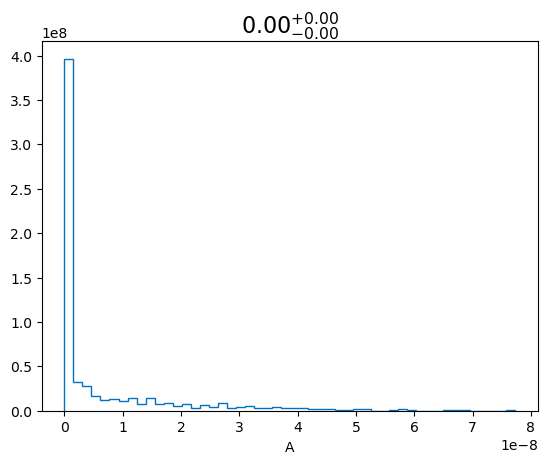

In [10]:
cleanup_dir(outdir)

alpha_fixed=0

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.DeltaFunction(alpha_fixed, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

95% UL = 3.385800e-08
95% UL from O2 paper = 3.500000e-08


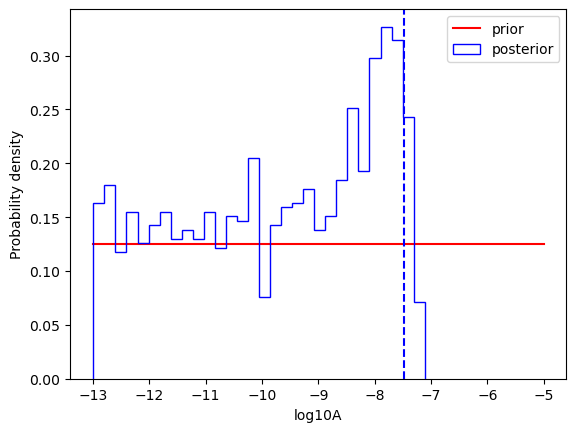

In [11]:
A=result.samples[:,0]


x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_a0)
plt.legend()

## alpha=2/3

14:46 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
14:46 bilby INFO    : Analysis priors:
14:46 bilby INFO    : A=LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
14:46 bilby INFO    : alpha=0.6666666666666666
14:46 bilby INFO    : Analysis likelihood class: <class '__main__.PowerLawGWBLikelihood'>
14:46 bilby INFO    : Analysis likelihood noise evidence: -26318.4730935049
14:46 bilby INFO    : Single likelihood evaluation took 9.730e-04 s
14:46 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 1024, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 'grad_args': None, 'grad_kwargs': None, 'compute_jac': False, 'enlarge': No

3552it [00:45, 22.54it/s, bound:0 nc: 61 ncall:3.5e+04 eff:10.2% logz-ratio=-0.21+/-0.02 dlogz:0.100>0.1]    

14:47 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


3554it [00:46, 76.46it/s, bound:0 nc:  1 ncall:3.6e+04 eff:13.1% logz-ratio=-0.11+/-0.01 dlogz:0.000>0.1]

14:47 bilby INFO    : Rejection sampling nested samples to obtain 1274 posterior samples
14:47 bilby INFO    : Sampling time: 0:00:46.466254
14:47 bilby INFO    : Summary of results:
nsamples: 1274
ln_noise_evidence: -26318.473
ln_evidence: -26318.581 +/-  0.031
ln_bayes_factor: -0.108 +/-  0.031



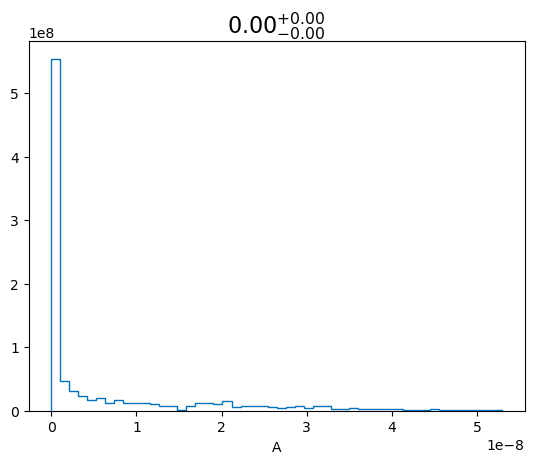

In [12]:
cleanup_dir(outdir)

alpha_fixed=2./3

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.DeltaFunction(alpha_fixed, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

95% UL = 3.098203e-08
95% UL from O2 paper = 3.000000e-08


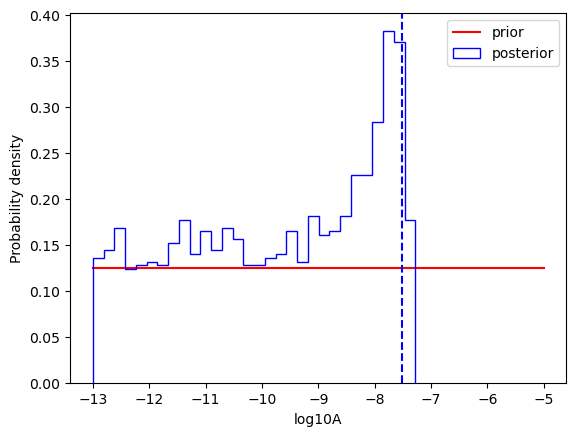

In [13]:
A=result.samples[:,0]

x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_a2_3)
plt.legend()

## alpha=3

14:47 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
14:47 bilby INFO    : Analysis priors:
14:47 bilby INFO    : A=LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
14:47 bilby INFO    : alpha=3
14:47 bilby INFO    : Analysis likelihood class: <class '__main__.PowerLawGWBLikelihood'>
14:47 bilby INFO    : Analysis likelihood noise evidence: -26318.4730935049
14:47 bilby INFO    : Single likelihood evaluation took 1.042e-03 s
14:47 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 1024, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 'grad_args': None, 'grad_kwargs': None, 'compute_jac': False, 'enlarge': None, 'bootstrap': 

3669it [00:43, 28.89it/s, bound:0 nc: 48 ncall:3.4e+04 eff:10.9% logz-ratio=-0.40+/-0.02 dlogz:0.100>0.1]    

14:48 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


3671it [00:45, 81.47it/s, bound:0 nc:  1 ncall:3.5e+04 eff:14.0% logz-ratio=-0.30+/-0.02 dlogz:0.000>0.1]

14:48 bilby INFO    : Rejection sampling nested samples to obtain 1309 posterior samples
14:48 bilby INFO    : Sampling time: 0:00:45.046135
14:48 bilby INFO    : Summary of results:
nsamples: 1309
ln_noise_evidence: -26318.473
ln_evidence: -26318.772 +/-  0.035
ln_bayes_factor: -0.299 +/-  0.035



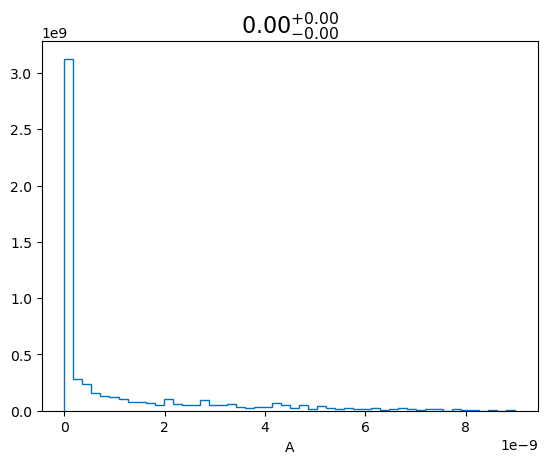

In [14]:
cleanup_dir(outdir)

alpha_fixed=3

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.DeltaFunction(alpha_fixed, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=20000)
result.plot_corner()

95% UL = 5.017453e-09
95% UL from O2 paper = 5.100000e-09


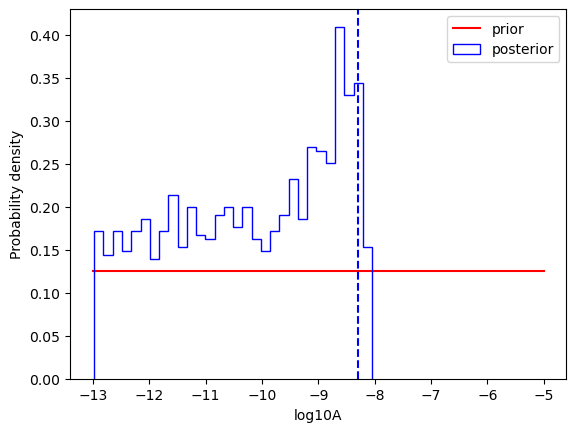

In [15]:
A=result.samples[:,0]

x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_a3)
plt.legend()

## Marginalize over alpha with Gaussian prior

* 0 mean
* 3.5 standard deviation
* gives similar results to triangle prior

14:48 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
14:48 bilby INFO    : Analysis priors:
14:48 bilby INFO    : A=LogUniform(minimum=1e-13, maximum=1e-05, name='A', latex_label='A', unit=None, boundary=None)
14:48 bilby INFO    : alpha=Gaussian(mu=0, sigma=3.5, name='alpha', latex_label='alpha', unit=None, boundary=None)
14:48 bilby INFO    : Analysis likelihood class: <class '__main__.PowerLawGWBLikelihood'>
14:48 bilby INFO    : Analysis likelihood noise evidence: -26318.4730935049
14:48 bilby INFO    : Single likelihood evaluation took 1.003e-03 s
14:48 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 1024, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 'grad_a

4110it [01:22, 29.12it/s, bound:34 nc: 19 ncall:6.0e+04 eff:6.8% logz-ratio=-0.35+/-0.02 dlogz:0.100>0.1]    

14:49 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4113it [01:24, 48.80it/s, bound:34 nc:  1 ncall:6.1e+04 eff:8.5% logz-ratio=-0.28+/-0.02 dlogz:0.000>0.1]

14:49 bilby INFO    : Rejection sampling nested samples to obtain 1196 posterior samples
14:49 bilby INFO    : Sampling time: 0:01:24.256870
14:49 bilby INFO    : Summary of results:
nsamples: 1196
ln_noise_evidence: -26318.473
ln_evidence: -26318.752 +/-  0.036
ln_bayes_factor: -0.279 +/-  0.036



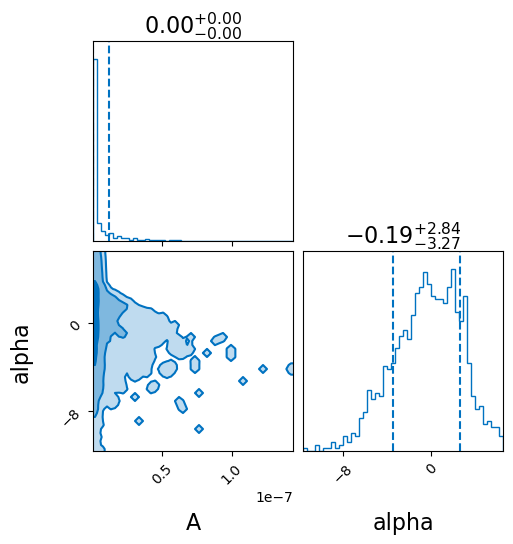

In [16]:
cleanup_dir(outdir)

alpha_mean=0
alpha_std=3.5

priors = dict(A=bilby.core.prior.LogUniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Gaussian(alpha_mean,alpha_std, 'alpha'))

# Run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=npoints,
    walks=10, outdir=outdir, label=label,maxmcmc=10000)
result.plot_corner()

In [17]:
A=result.samples[:,0]
alpha=result.samples[:,1]

95% UL = 3.485058e-08
95% UL from O2 paper = 3.400000e-08


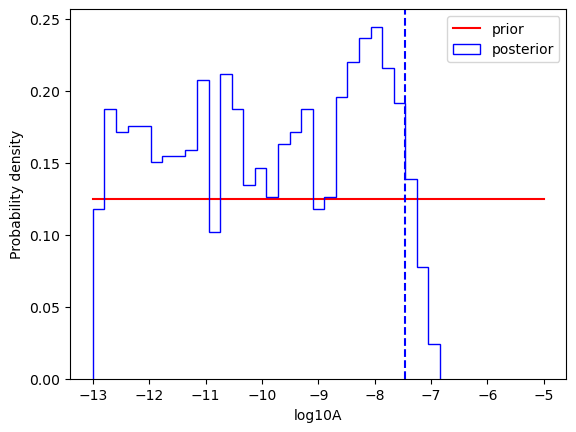

In [18]:
x=np.linspace(np.log10(Amax),np.log10(Amin),10)
prior=np.ones(x.shape)/(np.log10(Amax)-np.log10(Amin))
plt.plot(x,prior,color='red',label='prior')

plt.hist(np.log10(A),bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(np.log10(A),95),color='blue',linestyle='--')

plt.xlabel('log10A')
plt.ylabel('Probability density')

UL=np.percentile(A,95)
print('95%% UL = %e'%UL)
print('95%% UL from O2 paper = %e'%O2_UL_aMarg)

plt.legend()

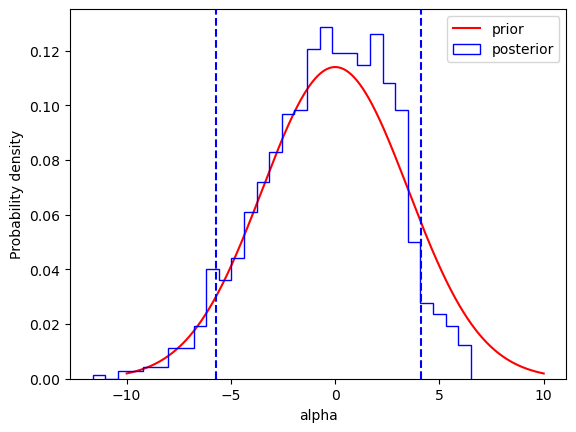

In [19]:
x=np.linspace(-10,10,1000)
prior=1/np.sqrt(2*np.pi*alpha_std**2) * np.exp(-0.5*(x/alpha_std)**2)
plt.plot(x,prior,color='red',label='prior')


plt.hist(alpha,bins=30,histtype='step',color='blue',density=True,label='posterior')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')


plt.xlabel('alpha')
plt.ylabel('Probability density')
plt.legend()

# some sanity checks

In [20]:
baselines[0].calibration_epsilon

0.07224956747275378

In [21]:
baselines[1].calibration_epsilon

0.04645696933722647